<a href="https://colab.research.google.com/github/iamnaymur/ml_meta_learning/blob/main/week05_advanced_supervised_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module - 16 :: Naive Bayes Classifier

In [1]:
print("hello")

hello


---
## Part A – Gaussian Naive Bayes on a Numeric Dataset

We start with the **Breast Cancer Wisconsin** dataset from `sklearn.datasets`.
This is a binary classification problem:
- Class 0: malignant
- Class 1: benign

Features are **continuous numeric measurements** of cell nuclei, so `GaussianNB` is appropriate.


In [2]:
# ===============================================================
# Imports and basic setup
# ===============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (7, 4)

### 1. Load and Inspect the Dataset

In [3]:
data = load_breast_cancer()
X = data.data
y = data.target

print('Shape of X (features):', X.shape)
print('Shape of y (labels):', y.shape)
print('Target names:', data.target_names)
print('\nFirst 5 feature names:')
print(data.feature_names[:5])

Shape of X (features): (569, 30)
Shape of y (labels): (569,)
Target names: ['malignant' 'benign']

First 5 feature names:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']


In [4]:
# Put into a DataFrame for easier viewing
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### 2. Class Distribution

target
1    357
0    212
Name: count, dtype: int64


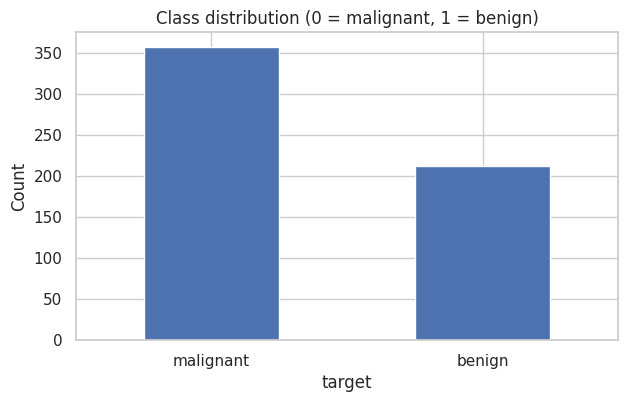

In [5]:
class_counts = df['target'].value_counts()
print(class_counts)

plt.figure()
class_counts.plot(kind='bar')
plt.xticks(ticks=[0,1], labels=data.target_names, rotation=0)
plt.title('Class distribution (0 = malignant, 1 = benign)')
plt.ylabel('Count')
plt.show()

### 3. Simple Feature Visualization

Let us plot one feature against the target to see if there is visible separation.

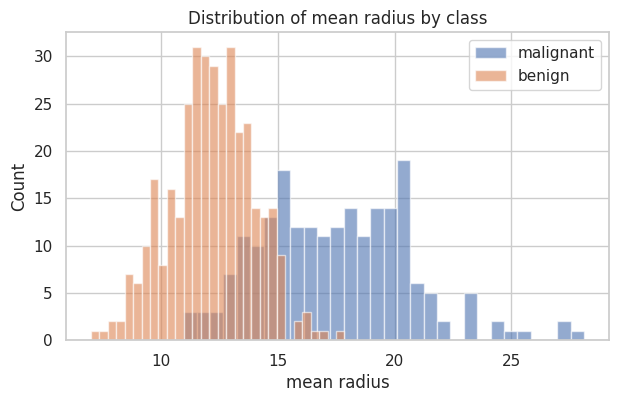

In [6]:
feature_name = 'mean radius'
feat_idx = list(data.feature_names).index(feature_name)

plt.figure()
plt.hist(X[y==0][:, feat_idx], bins=30, alpha=0.6, label='malignant')
plt.hist(X[y==1][:, feat_idx], bins=30, alpha=0.6, label='benign')
plt.legend()
plt.xlabel(feature_name)
plt.ylabel('Count')
plt.title(f'Distribution of {feature_name} by class')
plt.show()

### 4. Train–Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.25, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (426, 30)
Test set shape: (143, 30)


### 5. Train Gaussian Naive Bayes

In [8]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

GaussianNB()

### 6. Predictions and Accuracy

In [9]:
y_pred = gnb.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Accuracy on test set: ", acc)

Accuracy on test set:  0.9370629370629371


### 7. Confusion Matrix

Confusion matrix:
 [[46  7]
 [ 2 88]]


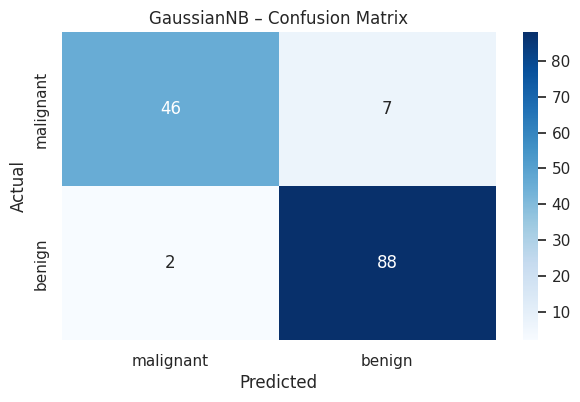

In [10]:
cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix:\n', cm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('GaussianNB – Confusion Matrix')
plt.show()

### 8. Classification Report

In [11]:
print(classification_report(y_test, y_pred, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.96      0.87      0.91        53
      benign       0.93      0.98      0.95        90

    accuracy                           0.94       143
   macro avg       0.94      0.92      0.93       143
weighted avg       0.94      0.94      0.94       143



### 9. Short Interpretation

- `precision` for malignant tells us: out of all samples predicted as malignant, how many were actually malignant.
- `recall` for malignant tells us: out of all truly malignant cases, how many we correctly caught.
- In medical tasks, **recall for malignant** is very important (missing a cancer case is risky).
- Naive Bayes uses **mean and variance** of each feature per class under the Gaussian assumption.


---
## Part B – Multinomial Naive Bayes on Text Data

Now we move to a **text classification** setting, where Naive Bayes is very powerful.
We will first use a tiny custom dataset for intuition, then show how to scale to a larger dataset.


### 1. Tiny Custom Sentiment Dataset

In [12]:
texts = [
    'I love this product',
    'This is amazing and fantastic',
    'I really like this',
    'I hate this item',
    'This is the worst thing ever',
    'Horrible and terrible experience',
]
labels = [1, 1, 1, 0, 0, 0]  # 1 = positive, 0 = negative

toy_df = pd.DataFrame({'text': texts, 'label': labels})
toy_df

,text,label
0,I love this product,1
1,This is amazing and fantastic,1
2,I really like this,1
3,I hate this item,0
4,This is the worst thing ever,0
5,Horrible and terrible experience,0


### 2. Convert Text to Features with CountVectorizer

In [13]:
vectorizer = CountVectorizer()
X_toy = vectorizer.fit_transform(toy_df['text'])
y_toy = toy_df['label']

print("Feature matrix shape: ", X_toy.shape)
print("Vocubulary: ", vectorizer.get_feature_names_out()) #every words in the texts, and then sorted it

Feature matrix shape:  (6, 18)
Vocubulary:  ['amazing' 'and' 'ever' 'experience' 'fantastic' 'hate' 'horrible' 'is'
 'item' 'like' 'love' 'product' 'really' 'terrible' 'the' 'thing' 'this'
 'worst']


### 3. Train MultinomialNB on Tiny Dataset

In [14]:
mnb_toy = MultinomialNB()
mnb_toy.fit(X_toy, y_toy)

y_toy_pred = mnb_toy.predict(X_toy)
print('Accuracy on tiny dataset: ', accuracy_score(y_toy,y_toy_pred))
print('Classification report: ')
print(classification_report(y_toy,y_toy_pred))

Accuracy on tiny dataset:  1.0
Classification report: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         3

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



### 4. Try New Sentences

In [15]:
new_texts = [
    'I love it',
    'This product is horrible',
    'Fantastic experience',
    'Worst purchase ever'
]
X_new = vectorizer.transform(new_texts)
new_pred = mnb_toy.predict(X_new)

for txt, pred in zip(new_texts, new_pred):
    label_str = 'positive' if pred == 1 else 'negative'
    print(f'{txt!r} -> {label_str}')

'I love it' -> positive
'This product is horrible' -> positive
'Fantastic experience' -> positive
'Worst purchase ever' -> negative


### 5. Scaling Up: 20 Newsgroups Subset

Now we use a **subset** of the classic 20 Newsgroups dataset.
We choose three categories to keep it manageable:
- `comp.graphics`
- `rec.sport.baseball`
- `sci.med`


In [16]:
from sklearn.datasets import fetch_20newsgroups

categories = ['comp.graphics', 'rec.sport.baseball', 'sci.med']

newsgroups = fetch_20newsgroups(
    subset = 'train',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),
    shuffle=True,
    random_state=42
)

In [17]:
df_news = pd.DataFrame({
    'text': newsgroups.data, #eitai x
    'label': newsgroups.target #eita Y
})
df_news.head()

,text,label
0,"\nThe FDA, I believe. Rules say no blood or b...",2
1,,2
2,It would be nice to think that individuals can...,2
3,"Ok all you trivia buffs, I have a good one for...",1
4,"Please , I need the starting address (pointer)...",0


In [18]:
print('Number of documents:', len(newsgroups.data))
print('Target names:', newsgroups.target_names)

Number of documents: 1775
Target names: ['comp.graphics', 'rec.sport.baseball', 'sci.med']


#### Train–Test Split for News Text

In [19]:
X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    df_news['text'], df_news['label'], test_size=0.25, random_state=42
)

print('Train size:', X_train_text.shape[0])
print('Test size:', X_test_text.shape[0])

Train size: 1331
Test size: 444


#### Vectorize Text with CountVectorizer

In [20]:
"""
-> stop words are like is, a , was and bla bla. Eigula to freq ashei, but eigula neyar kono dorkar nai


-> max_feature ,,jodi proti ta word ke alada alada feature hisabe consider kori, taile to 50k-100k featurse hoye jabe. Thats why we using max_features = 3000,  jaar mane sobcheye freq top 3000 words we will consider
"""
vectorizer_news = CountVectorizer(stop_words='english', max_features=3000)
X_train_counts = vectorizer_news.fit_transform(X_train_text)
X_test_counts = vectorizer_news.transform(X_test_text)

print('Shape of X_train_counts:', X_train_counts.shape)
print('Shape of X_test_counts:', X_test_counts.shape)

Shape of X_train_counts: (1331, 3000)
Shape of X_test_counts: (444, 3000)


#### Train MultinomialNB on News Data

In [21]:
mnb_news = MultinomialNB()
mnb_news.fit(X_train_counts, y_train_text)
print('MultinomialNB model train DONE on news data.')

MultinomialNB model train DONE on news data.


#### Evaluate MultinomialNB on News Data

Accuracy on 20 Newsgroups subset: 0.9166666666666666
Confusion matrix:
 [[131   5   7]
 [  6 132   9]
 [  4   6 144]]


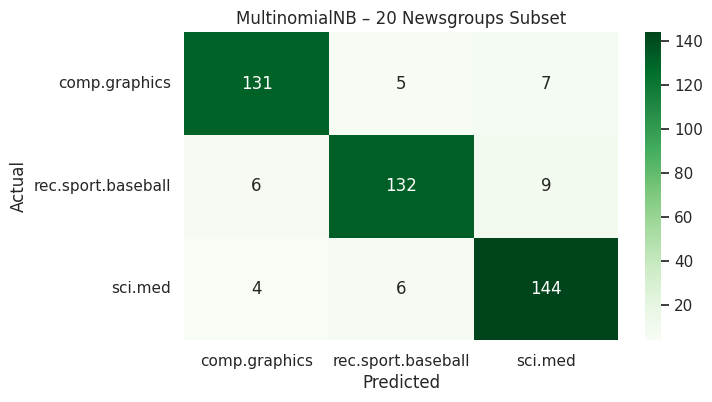

Classification report:
                    precision    recall  f1-score   support

     comp.graphics       0.93      0.92      0.92       143
rec.sport.baseball       0.92      0.90      0.91       147
           sci.med       0.90      0.94      0.92       154

          accuracy                           0.92       444
         macro avg       0.92      0.92      0.92       444
      weighted avg       0.92      0.92      0.92       444



In [22]:
y_news_pred = mnb_news.predict(X_test_counts)
acc_news = accuracy_score(y_test_text, y_news_pred)
print('Accuracy on 20 Newsgroups subset:', acc_news)

cm_news = confusion_matrix(y_test_text, y_news_pred)
print('Confusion matrix:\n', cm_news)

sns.heatmap(cm_news, annot=True, fmt='d', cmap='Greens',
            xticklabels=newsgroups.target_names,
            yticklabels=newsgroups.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('MultinomialNB – 20 Newsgroups Subset')
plt.show()

print('Classification report:')
print(classification_report(y_test_text, y_news_pred,
                            target_names=newsgroups.target_names))

---
## Summary

In this notebook we have seen how to:

**Numeric data (GaussianNB):**
- Load a real dataset (breast cancer)
- Explore class balance and simple feature distributions
- Train a Gaussian Naive Bayes model
- Evaluate with accuracy, confusion matrix, and classification report

**Text data (MultinomialNB):**
- Build a tiny custom sentiment dataset for intuition
- Use `CountVectorizer` to convert text into word count features
- Train `MultinomialNB` and test on new sentences
- Scale the same idea to a real text dataset (20 Newsgroups subset)
- Evaluate performance on multi class text classification




---



# Module - 17 ::: K-Nearest Neighbour (KNN)  

This notebook covers the following sections for **KNN Classification**:
1. **Training & Prediction Process**
2. **Implementing KNN on a Dataset**
3. **Model Evaluation & Optimization**


## 0) Setup
We will use:
- `StandardScaler` because KNN depends on distances
- `KNeighborsClassifier` for classification
- A clean sklearn `Pipeline` to learn the correct workflow


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report
)

np.random.seed(42)


## 1) Training & Prediction Process (sklearn view)

### What “training” means for KNN
KNN is called a **lazy learner** because it does not learn weights or coefficients.

In practice, `.fit()` does two important things:
- Fits the scaler on training data (learns mean and standard deviation)
- Stores the training examples inside the KNN model

So training is fast, but prediction can be expensive.

### What prediction means
During `.predict()` KNN does:
1. Compute distance from the query point to all stored training points  
2. Sort distances  
3. Select the K nearest neighbors  
4. Majority vote for the predicted class  

That is why KNN can become slow when the dataset is large.


## Why scaling is non-negotiable
KNN uses distance. Distance is scale-sensitive.

If one feature has a much larger range than others, it dominates distance and breaks neighbor selection.
So we always place `StandardScaler` before KNN in the pipeline.


## 2) Implementing KNN on a Dataset

We use the **Wine dataset** (3 classes). It is good for learning because:
- All features are numeric
- Multi-class classification feels realistic
- Scaling matters

Pipeline we follow:
1. Train-test split  
2. Pipeline = scaling + KNN  
3. Fit on training data  
4. Predict on test data  
5. Evaluate  


In [24]:
wine = load_wine()
X = wine.data
y = wine.target

print("Dataset shape:", X.shape)
print("Classes:", list(wine.target_names))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


Dataset shape: (178, 13)
Classes: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


In [25]:
# Baseline KNN model (Euclidean distance via Minkowski p=2)
clf = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=15, metric="minkowski", p=2))
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

## 3) Model Evaluation & Optimization

We will tune K by trying a range of values and plotting accuracy.

Note:
- This uses the test split for a simple classroom demo.
- In serious ML work, use cross-validation.


In [26]:
#We will tune K by trying a range of values and plotting accuracy.
k_values = range(1,42)
accs = []
for k in k_values:
  model = Pipeline([
      ("scaler", StandardScaler()),
      ("knn", KNeighborsClassifier(n_neighbors= k))
  ])
  model.fit(X_train, y_train)
  pred = model.predict(X_test)
  accs.append(accuracy_score(y_test, pred))

In [27]:
print(accs)

[0.9555555555555556, 0.9333333333333333, 0.9555555555555556, 0.9333333333333333, 0.9333333333333333, 0.9333333333333333, 0.9777777777777777, 0.9555555555555556, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 1.0, 0.9777777777777777, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9777777777777777, 0.9777777777777777, 0.9555555555555556, 0.9555555555555556, 0.9555555555555556, 0.9777777777777777, 0.9555555555555556, 0.9555555555555556, 0.9555555555555556, 0.9555555555555556, 0.9111111111111111, 0.9333333333333333, 0.9111111111111111, 0.9111111111111111, 0.9111111111111111, 0.9555555555555556, 0.9111111111111111, 0.9333333333333333]


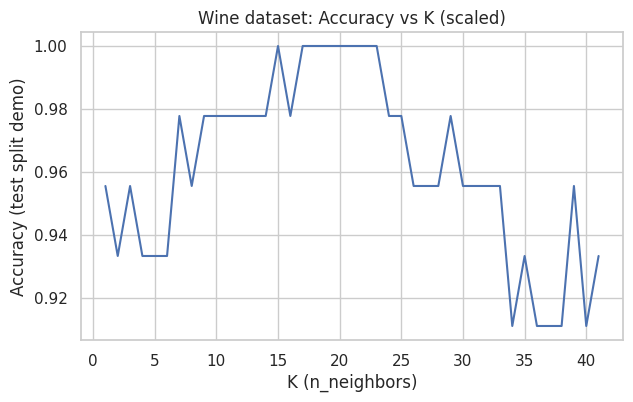

Best K (by this demo): 15
Best accuracy: 1.0


In [28]:
plt.figure()
plt.plot(list(k_values), accs)
plt.xlabel("K (n_neighbors)")
plt.ylabel("Accuracy (test split demo)")
plt.title("Wine dataset: Accuracy vs K (scaled)")
plt.show()

best_k = list(k_values)[int(np.argmax(accs))]
print("Best K (by this demo):", best_k)
print("Best accuracy:", float(np.max(accs)))

## Compare distance metrics and voting weights

We compare:
- Euclidean distance (p=2)
- Manhattan distance (p=1)
- Euclidean with distance-weighted voting

Goal: Show that KNN is not “one model”. Its behavior depends on your choices.


In [29]:
#Compare distance metrics and voting weights
k_demo = best_k

settings = [
    ("Euclidean (p=2), uniform", KNeighborsClassifier(n_neighbors=k_demo, metric="minkowski",p=2,weights="uniform")),
    ("Manhattan (p=1), uniform", KNeighborsClassifier(n_neighbors=k_demo, metric="minkowski",p=1,weights="uniform")),
    ("Euclidean (p=2), distance", KNeighborsClassifier(n_neighbors=k_demo, metric="minkowski",p=2,weights="distance")),
]

rows = []
for name,knn in settings:
  model = Pipeline([("scaler", StandardScaler()), ("knn",knn)])
  model.fit(X_train, y_train)
  pred = model.predict(X_test)
  rows.append([name, accuracy_score(y_test,pred)])

pd.DataFrame(rows, columns=["Setting", "Accuracy"]).sort_values("Accuracy", ascending=False)

,Setting,Accuracy
0,"Euclidean (p=2), uniform",1.000000
2,"Euclidean (p=2), distance",1.000000
1,"Manhattan (p=1), uniform",0.977778


## Optional: What changes if you forget scaling?

This cell trains KNN **without scaling** and compares accuracy.


In [30]:
# KNN without scaling (intentionally)
knn_no_scale = KNeighborsClassifier(n_neighbors=best_k)
knn_no_scale.fit(X_train, y_train)
pred_no_scale = knn_no_scale.predict(X_test)

acc_no_scale = accuracy_score(y_test, pred_no_scale)

# KNN with scaling (pipeline)
pred_scaled = clf.predict(X_test)
acc_scaled = accuracy_score(y_test, pred_scaled)

print("Accuracy without scaling:", float(acc_no_scale))
print("Accuracy with scaling:", float(acc_scaled))


Accuracy without scaling: 0.7777777777777778
Accuracy with scaling: 1.0


In [31]:
print("Accuracy:", float(accuracy_score(y_test, y_pred)))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=wine.target_names))

Accuracy: 1.0

Confusion Matrix:
 [[15  0  0]
 [ 0 18  0]
 [ 0  0 12]]

Classification Report:
               precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        15
     class_1       1.00      1.00      1.00        18
     class_2       1.00      1.00      1.00        12

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



## Key KNN parameters one must know

- `n_neighbors` (K): number of neighbors consulted  
- `metric`: how distance is computed  
- `p` (for Minkowski):  
  - p = 2 means Euclidean  
  - p = 1 means Manhattan  
- `weights`:  
  - `uniform`: all neighbors vote equally  
  - `distance`: closer neighbors vote more  


#Module - 18 :: Random Forest


## 1. Why Random Forest Here?

Random Forest is one of the strongest baseline models for tabular data.

Why?
- It handles non-linear relationships
- It is resistant to overfitting compared to a single decision tree
- It requires minimal preprocessing
- It works well even when feature interactions are complex

We will now implement it step by step.


In [32]:
#Importing Necessary Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## 2. Dataset Selection

We use the **Breast Cancer Wisconsin dataset** from sklearn.

Why this dataset?
- Clean and well-structured
- Binary classification
- Medical context encourages careful evaluation
- Non-linear patterns suit Random Forest well


In [33]:
#Dataset Loadin
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (569, 30)
Target shape: (569,)


In [34]:
#Understanding the Target Variable
y.value_counts()

,count
target,
1,357
0,212



## 3. Train-Test Split

We split the data into:
- Training set (75%)
- Test set (25%)

We use **stratification** to preserve class balance.


In [35]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 426
Test samples: 143



## 4. Training a Baseline Random Forest Model

We start with a simple Random Forest using default-friendly parameters.
No tuning yet.


In [43]:
#Baseline Random Forest Model
rf_baseline = RandomForestClassifier(
    n_estimators=100, #means -> koyta decision tree thakbe
    random_state=42
)

rf_baseline.fit(X_train, y_train)

RandomForestClassifier(random_state=42)


## 5. Making Predictions


In [44]:
#Making Predictions
y_pred = rf_baseline.predict(X_test)


## 6. Model Evaluation

Accuracy alone is **not enough**, especially in healthcare problems.


In [45]:
#Model Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.958041958041958



### Classification Report

This shows:
- Precision
- Recall
- F1-score

Recall is especially important here because false negatives are dangerous.


In [46]:
#Classification Report
print(classification_report(y_test, y_pred, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.96      0.92      0.94        53
      benign       0.96      0.98      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143




### Confusion Matrix


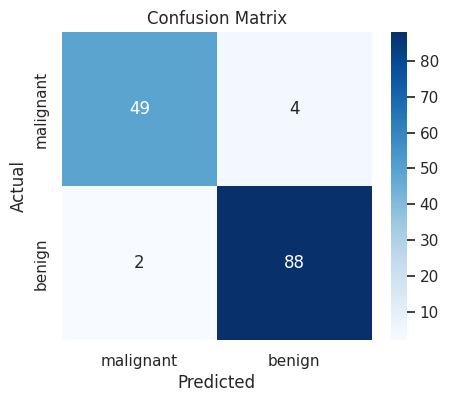

In [47]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


## 7. Feature Importance

Random Forest provides **global feature importance**.
This tells us which features were most useful overall.


In [48]:
#Feature Importance
importances = pd.Series(
    rf_baseline.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importances.head(10)

,0
worst area,0.149674
worst concave points,0.127189
mean concave points,0.104650
worst radius,0.086963
worst perimeter,0.080299
mean perimeter,0.080037
mean concavity,0.055420
mean radius,0.053665
mean area,0.044062
area error,0.024557


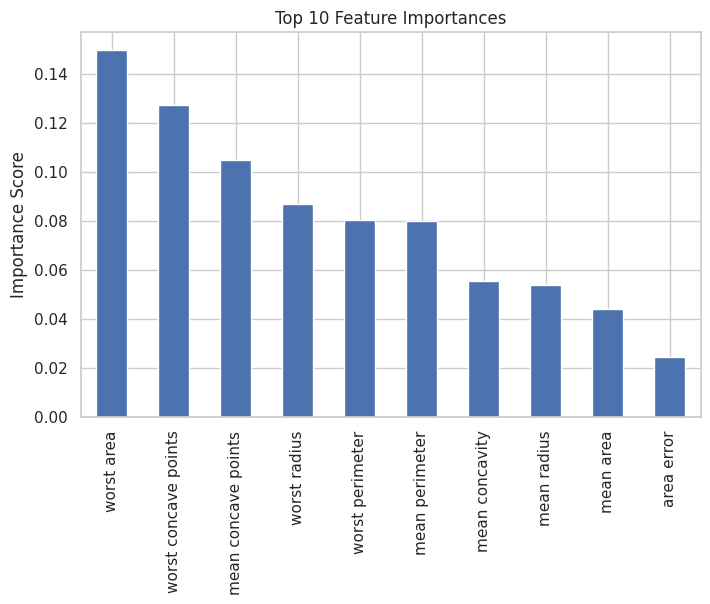

In [50]:
#Visualisation
plt.figure(figsize=(8,5))
importances.head(10).plot(kind="bar")
plt.title("Top 10 Feature Importances")
plt.ylabel("Importance Score")
plt.show()


Important note:
Feature importance explains the model globally, not individual predictions.



## 8. Why Hyperparameter Tuning Matters

Problems with default settings:
- Trees may be too deep
- Model may overfit
- Training may be unnecessarily slow

We tune **structure**, not vanity metrics.



## 9. Key Hyperparameters

- n_estimators: number of trees
- max_depth: tree depth
- min_samples_split:  minimum kotogula samples thakle split korbe
- max_features: how many features the tree randomly considers when deciding each split

In [51]:
#Key Hyperparameters
param_grid ={
    "n_estimators": [ 100,150, 175, 200],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2,3, 5],
    "max_features": ["auto", "sqrt", "log2"]
}


## 10. GridSearchCV for Tuning


In [52]:
# gridsearchCv for tuning
# this tries every possible combination in the training phase and get the best one

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5, # overall dataset re vaag korbe 5 vage, 4 vag training and 1 vag testing  e.. and ei kaj tao hobe 5 times
    n_jobs=-1,
    scoring = "f1" #Use all available CPU cores to do the calculation
)


grid_rf.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
240 fits failed out of a total of 720.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
98 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/usr/local/lib/python3.13/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_p

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10, 15],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'min_samples_split': [2, 3, 5],
                         'n_estimators': [100, 150, 175, 200]},
             scoring='f1')

In [53]:
#Showing outputs
print("Best parameters found:")
print(grid_rf.best_params_)

Best parameters found:
{'max_depth': 5, 'max_features': 'log2', 'min_samples_split': 3, 'n_estimators': 100}



## 11. Evaluating the Tuned Model


In [54]:
#Evaluating the Tuned Model
best_rf = grid_rf.best_estimator_
y_pred_best = best_rf.predict(X_test)

print(classification_report(y_test, y_pred_best, target_names=data.target_names))


              precision    recall  f1-score   support

   malignant       0.96      0.92      0.94        53
      benign       0.96      0.98      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143




## 12. Final Takeaways

- Random Forest is strong out of the box
- Evaluation must go beyond accuracy
- Feature importance provides insight, not full explanation
- Hyperparameter tuning improves robustness, not miracles
